In [12]:
import numpy as np
import matplotlib.pyplot as plt

<h2>Machine learning & NN </h2>

In [8]:
from sklearn.linear_model import LogisticRegression
#training data
X = [
    [1, 100, 1],    # [num_links, email_length, num_spam_words]
    [0, 50, 0],
    [3, 200, 5],
    [2, 150, 2],
    [0, 70, 0],
    [4, 300, 6]
]
# Labels: 0 = Not Spam, 1 = Spam
y = [0, 0, 1, 0, 0, 1]
model = LogisticRegression()
model.fit(X, y) #train the model
# New email comming
test = [[26, 1, 5]]
#
result = model.predict(test)
print(result)

[0]


<h2>Unsupervised Learning (Clustering)</h2>

In [17]:
def draw_clusters(model):
    # Get cluster labels
    labels = model.labels_
    # Get cluster centers
    centers = model.cluster_centers_
    # Plot points
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    # Plot centers
    plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)
    plt.title("KMeans Clustering")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

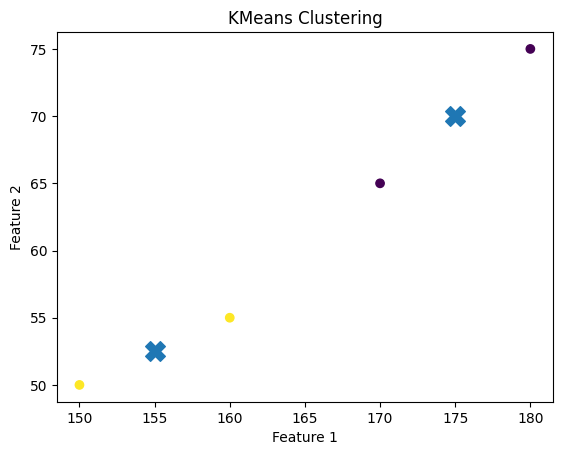

Cluster: [0]


In [24]:
# Unsupervised Learning: KMeans Clustering
from sklearn.cluster import KMeans
# Data: height and weight
X = np.array([
    [150, 50],
    [160, 55],
    [170, 65],
    [180, 75]
])
model = KMeans(n_clusters=2)
model.fit(X)

draw_clusters(model)

cluster = model.predict([[175, 60]])
print("Cluster:", cluster)

In [22]:
# Reinforcement Learning (simple idea using random rewards)
import random

actions = ["left", "right"]
rewards = {"left": 0, "right": 0}

# Try actions multiple times
for i in range(10):
    action = random.choice(actions)

    # Simulate reward
    if action == "right":
        reward = 1   # good action
    else:
        reward = 0   # bad action

    rewards[action] += reward

print("Total rewards:", rewards)

Total rewards: {'left': 0, 'right': 7}


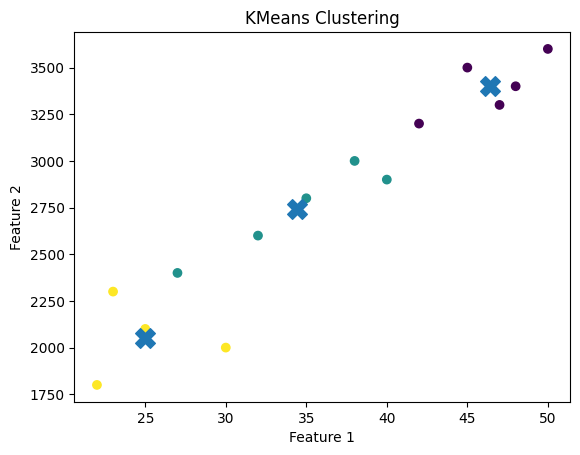

Cluster: [2]


In [32]:
#age, income (usd)
X = np.array([
    # Group 1: Young, low income
    [22, 1800],
    [23, 2300],
    [25, 2100],
    [27, 2400],
    [30, 2000],
    # Group 2: Middle age, medium income
    [32, 2600],
    [35, 2800],
    [38, 3000],
    [40, 2900],
    # Group 3: Older, high income
    [42, 3200],
    [45, 3500],
    [47, 3300],
    [48, 3400],
    [50, 3600]
])
model = KMeans(n_clusters=3)
model.fit(X)

draw_clusters(model)

cluster = model.predict([[175, 60]])
print("Cluster:", cluster)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# X = [hours studied, sleep hours]
X = np.array([
    [1, 5],
    [2, 6],
    [3, 6],
    [4, 7],
    [5, 8]
], dtype=float)

y = np.array([5, 5.5, 6.5, 7, 7.5], dtype=float)    #score after learning

model = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)), #8 neurons in hidden layer, relu: non-linear patterns
    layers.Dense(1)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train model
model.fit(X, y, epochs=100, verbose=0)

# Predict
prediction = model.predict(np.array([[6, 7]]))
print("Predicted score:", prediction[0][0])

/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Predicted score: 8.33849


<h2>NLP</h2>

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

sentences = [
    "I love pizza",
    "I like pizza",
    "I hate rain"
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(sentences)

similarity = cosine_similarity(X)

for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        print(f'"{sentences[i]}" vs "{sentences[j]}" = {similarity[i][j]:.2f}')
# print(similarity) #matrix, hard to understand

"I love pizza" vs "I like pizza" = 0.37
"I love pizza" vs "I hate rain" = 0.00
"I like pizza" vs "I hate rain" = 0.00


In [ ]:
#detect comment purpose
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# Training data
texts = [
    "This product is amazing",
    "I love this",
    "This is great",
    "I hate this app",
    "This is terrible",
    "Very bad experience",
    "It is okay",
    "Not great, not bad",
    "Average product"
]

# Labels: Positive / Negative / Neutral
labels = [
    "positive",
    "positive",
    "positive",
    "negative",
    "negative",
    "negative",
    "neutral",
    "neutral",
    "neutral"
]

# Convert text → numbers
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# Train model
model = LogisticRegression()
model.fit(X, labels)

# Test sentences
test_sentences = [
    "This product is amazing",
    "I hate this app",
    "It's okay, not great"
]

X_test = vectorizer.transform(test_sentences)

# Predict
predictions = model.predict(X_test)

# Show results
for sentence, pred in zip(test_sentences, predictions):
    print(f'"{sentence}" → {pred}')

"This product is amazing" → positive
"I hate this app" → negative
"It's okay, not great" → neutral


<h2>CV</h2>
python3.10 -m pip install pytesseract opencv-python pillow

In [48]:
import cv2
import pytesseract

# 1. Chỉ định đường dẫn file thực thi tesseract (Nếu dùng Windows)
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
def detect_text(image_path):
    # 2. Đọc ảnh bằng OpenCV
    img = cv2.imread(image_path)
    # 3. Tiền xử lý: Chuyển sang ảnh xám để máy dễ đọc hơn
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # 4. Nhận diện chữ
    text = pytesseract.image_to_string(gray, lang='eng')
    return text

image_file = "text_detection.jpg"
print(detect_text(image_file))


[ExT 03 |

© = SIGN’
STEALERS =>

